In [6]:
pip install gsw

  Using cached gsw-3.6.21-cp311-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (7.0 kB)
  Using cached numpy-2.4.4-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached gsw-3.6.21-cp311-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (2.4 MB)
Using cached numpy-2.4.4-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:━━━━━━━━━━━━━━━━━━ 0/2 [numpy]
      Successfully uninstalled numpy-1.26.4━━━━━ 0/2 [numpy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/2 [numpy]  WARNING: Failed to remove contents in a temporary directory '/orcd/home/002/codycruz/Ocean_Emulator/.venv/lib/python3.11/site-packages/~=mpy.libs'.
  You can safely remove it manually.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/2 [numpy]  WARNING: Failed to remove contents in a temporary directory '/orcd

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import dask
import zarr
import xarray as xr
import cmocean
import gsw

In [2]:
llc_path = '/orcd/data/abodner/002/cody/LLC_patch/LLC4320_face1_i2880-3600_j720-1440.zarr'
llc_patch_full = xr.open_dataset(llc_path, consolidated=True)

emulator_path = '/orcd/data/abodner/002/cody/inference_patch/predictions/2026-03-26-eval:samudra_llc:epoch1_oct2012_patchloc=i(2880,3600)-j(720,1440)/predictions_4d.zarr'
emulator_patch_full = xr.open_dataset(emulator_path, consolidated=True)
#emulator_patch_full = xr.open_dataset(llc_path, consolidated=True)

In [3]:
extent = 1
start_offset=0
llc_patch = llc_patch_full.isel(time=slice(start_offset+9216, start_offset+9216 + extent))
emulator_patch = emulator_patch_full.isel(time=slice(start_offset+0, extent + start_offset))

In [ ]:
Theta_hist_llc = llc_patch.Theta.stack(vals=['time','i','j']).values[:,::10]
Theta_hist_emulator = emulator_patch.Theta.stack(vals=['time','lon','lat']).values[:,::10]

Salt_hist_llc = llc_patch.Salt.stack(vals=['time','i','j']).values[:,::10]
Salt_hist_emulator = emulator_patch.Salt.stack(vals=['time','lon','lat']).values[:,::10]

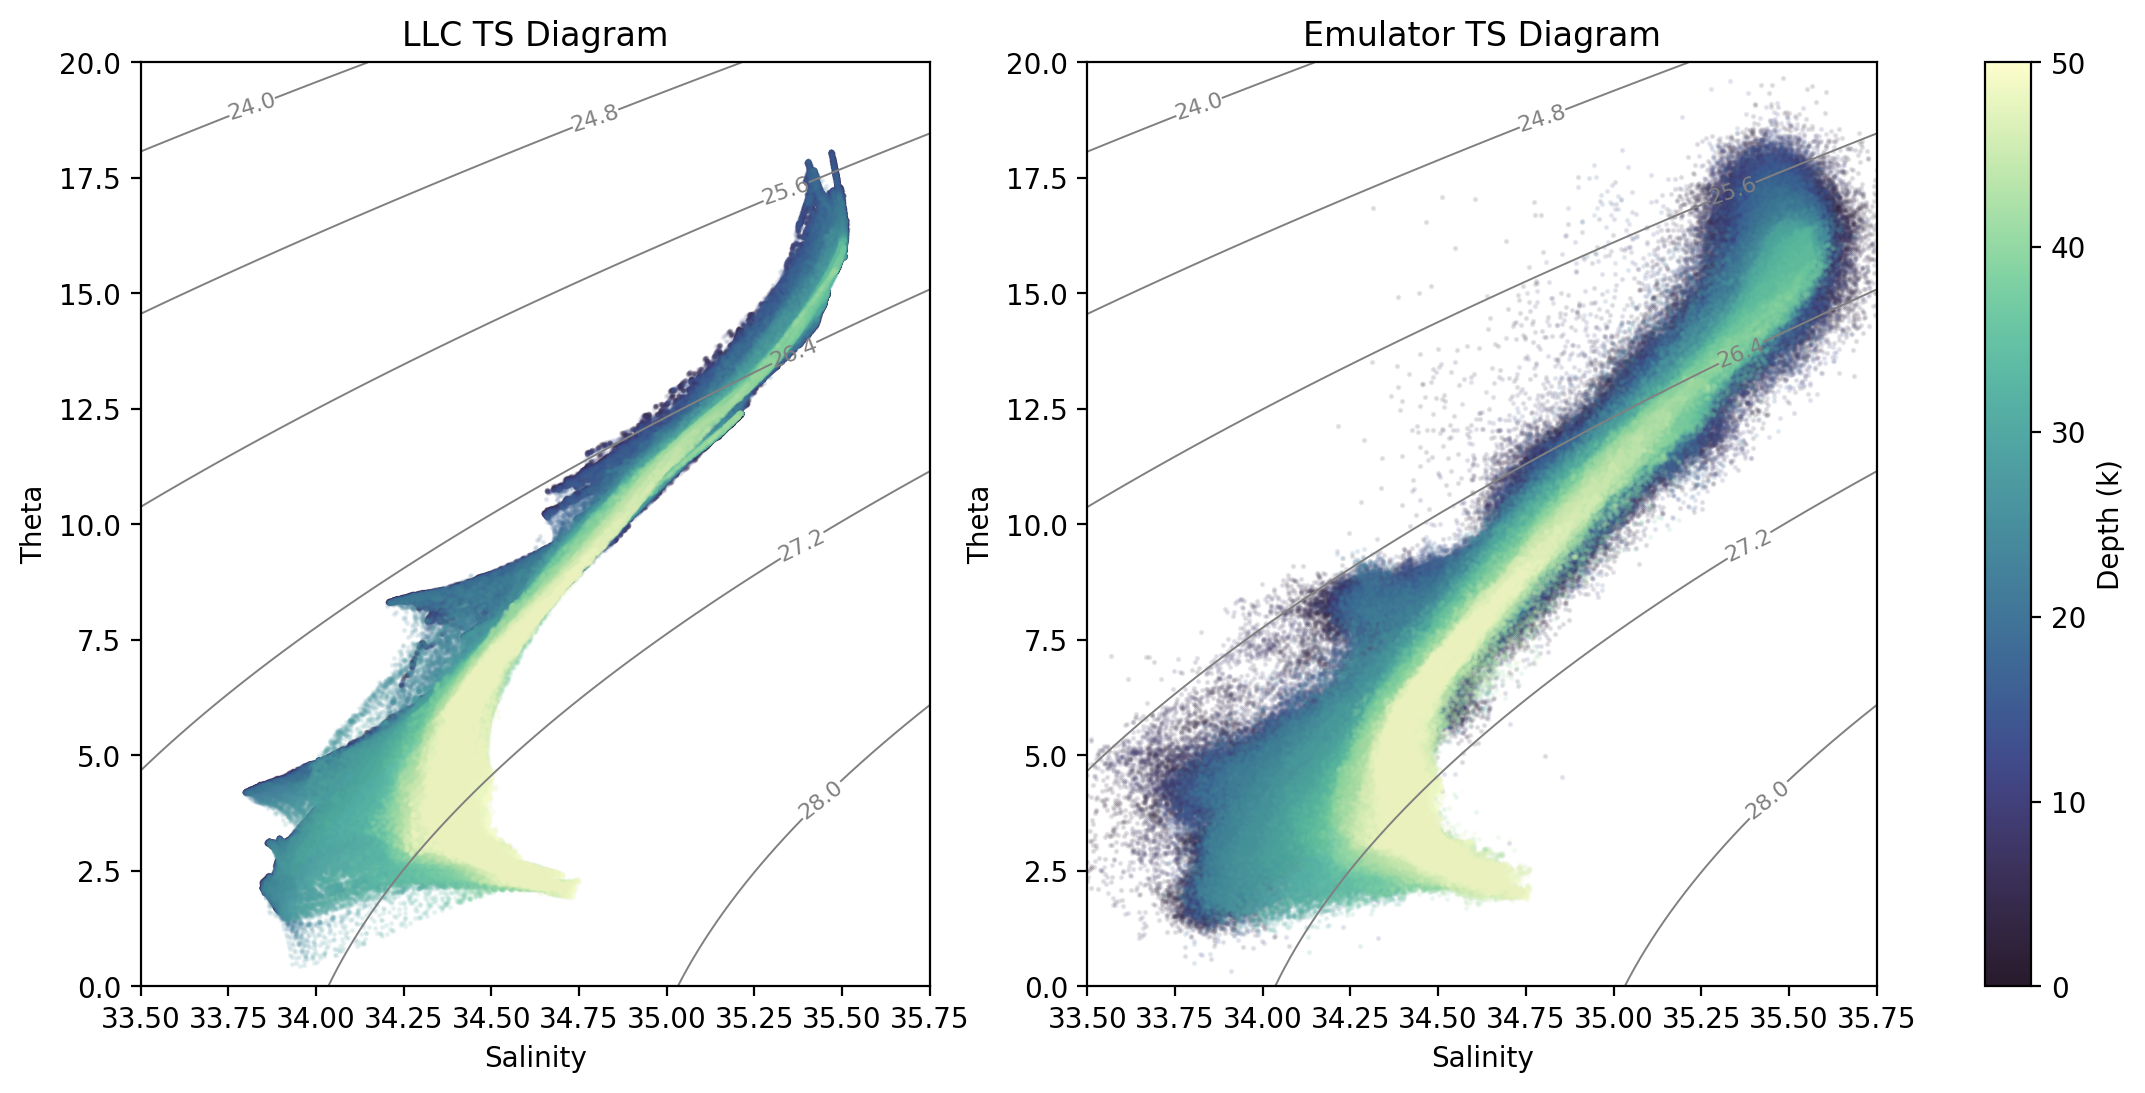

In [ ]:

# generate TS grid
T = np.linspace(0,20,100)
S = np.linspace(33.5,35.75,100)
Sg, Tg = np.meshgrid(S,T)

sigma = gsw.sigma0(Sg,Tg)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=200)

# LLC TS diagram
cs1 = ax1.contour(Sg, Tg, sigma, colors='grey', linewidths=0.7)
ax1.clabel(cs1, inline=1, fontsize=8, fmt="%.1f")
for k in range(len(Salt_hist_llc)):
    ax1.scatter(Salt_hist_llc[k], Theta_hist_llc[k], 
                c=[cmocean.cm.deep_r(k/len(Salt_hist_llc))], s=1, alpha=0.1)
ax1.set_xlabel("Salinity")
ax1.set_ylabel("Theta")
ax1.set_title("LLC TS Diagram")

# Emulator TS diagram
cs2 = ax2.contour(Sg, Tg, sigma, colors='grey', linewidths=0.7)
ax2.clabel(cs2, inline=1, fontsize=8, fmt="%.1f")
for k in range(len(Salt_hist_emulator)):
    ax2.scatter(Salt_hist_emulator[k], Theta_hist_emulator[k], 
                c=[cmocean.cm.deep_r(k/len(Salt_hist_emulator))], s=1, alpha=0.1)
ax2.set_xlabel("Salinity")
ax2.set_ylabel("Theta")
ax2.set_title("Emulator TS Diagram")
ax2.set_xlim(33.5,35.75)

# Shared depth colorbar
sm = plt.cm.ScalarMappable(cmap=cmocean.cm.deep_r, norm=plt.Normalize(vmin=0, vmax=len(Salt_hist_llc)-1))
sm.set_array([])
plt.colorbar(sm, ax=[ax1, ax2], label='Depth (k)')

#plt.tight_layout()
plt.savefig('figs/TS/LLC_vs_Emulator_TS,t=0.png')
plt.show()
#plt.close()

In [84]:
extent = 1
start_offset=6
llc_patch = llc_patch_full.isel(time=slice(start_offset+9216, start_offset+9216 + extent))
emulator_patch = emulator_patch_full.isel(time=slice(start_offset+0, extent + start_offset))

In [85]:
Theta_hist_llc = llc_patch.Theta.stack(vals=['time','i','j']).values[:,::10]
Theta_hist_emulator = emulator_patch.Theta.stack(vals=['time','lon','lat']).values[:,::10]

Salt_hist_llc = llc_patch.Salt.stack(vals=['time','i','j']).values[:,::10]
Salt_hist_emulator = emulator_patch.Salt.stack(vals=['time','lon','lat']).values[:,::10]

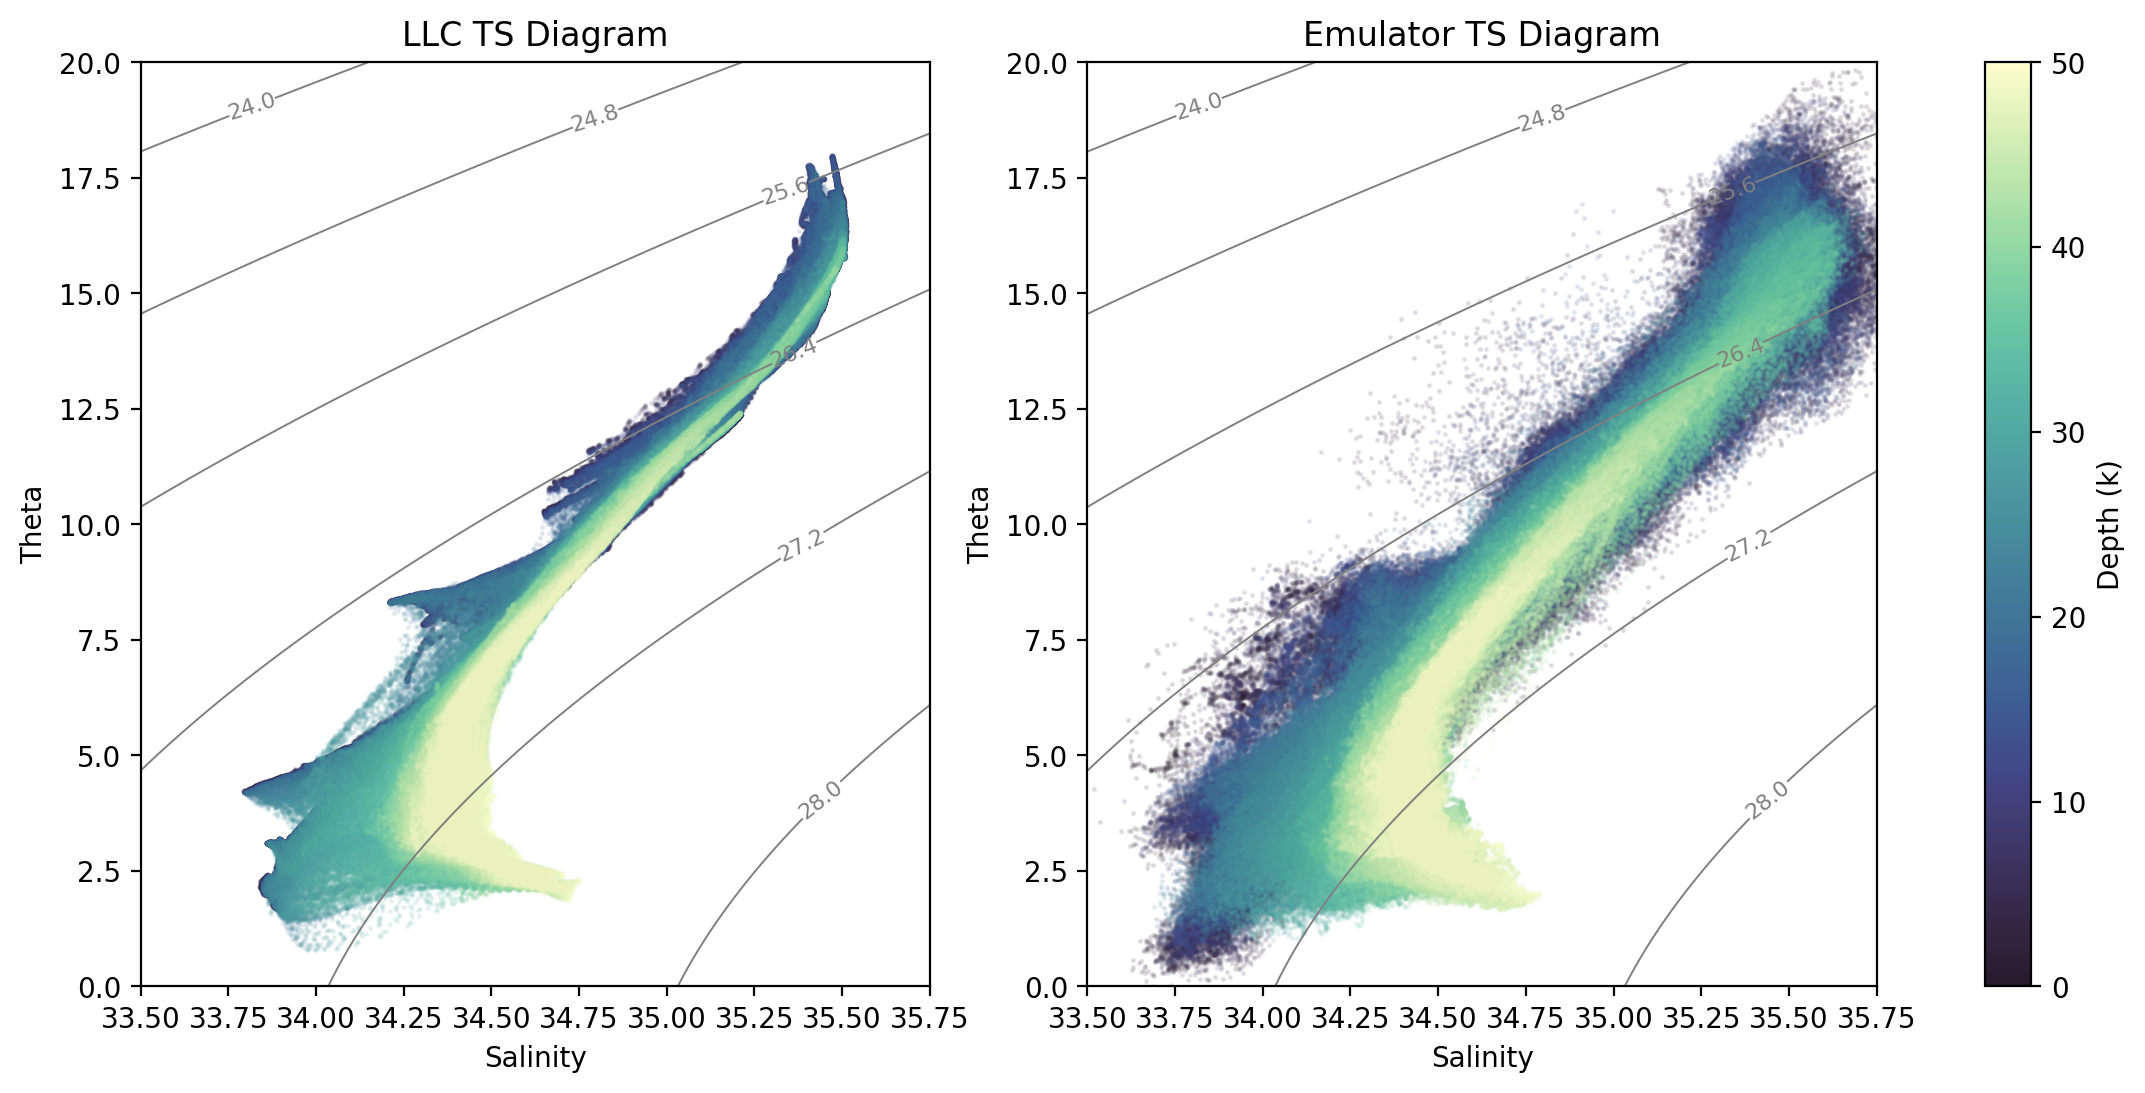

In [86]:
# generate TS grid
T = np.linspace(0,20,100)
S = np.linspace(33.5,35.75,100)
Sg, Tg = np.meshgrid(S,T)

sigma = gsw.sigma0(Sg,Tg)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=200)

# LLC TS diagram
cs1 = ax1.contour(Sg, Tg, sigma, colors='grey', linewidths=0.7)
ax1.clabel(cs1, inline=1, fontsize=8, fmt="%.1f")
for k in range(len(Salt_hist_llc)):
    ax1.scatter(Salt_hist_llc[k], Theta_hist_llc[k], 
                c=[cmocean.cm.deep_r(k/len(Salt_hist_llc))], s=1, alpha=0.1)
ax1.set_xlabel("Salinity")
ax1.set_ylabel("Theta")
ax1.set_title("LLC TS Diagram")

# Emulator TS diagram
cs2 = ax2.contour(Sg, Tg, sigma, colors='grey', linewidths=0.7)
ax2.clabel(cs2, inline=1, fontsize=8, fmt="%.1f")
for k in range(len(Salt_hist_emulator)):
    ax2.scatter(Salt_hist_emulator[k], Theta_hist_emulator[k], 
                c=[cmocean.cm.deep_r(k/len(Salt_hist_emulator))], s=1, alpha=0.1)
ax2.set_xlabel("Salinity")
ax2.set_ylabel("Theta")
ax2.set_title("Emulator TS Diagram")
ax2.set_xlim(33.5,35.75)

# Shared depth colorbar
sm = plt.cm.ScalarMappable(cmap=cmocean.cm.deep_r, norm=plt.Normalize(vmin=0, vmax=len(Salt_hist_llc)-1))
sm.set_array([])
plt.colorbar(sm, ax=[ax1, ax2], label='Depth (k)')

#plt.tight_layout()
plt.savefig('figs/TS/LLC_vs_Emulator_TS,t=6.png')
plt.show()
#plt.close()

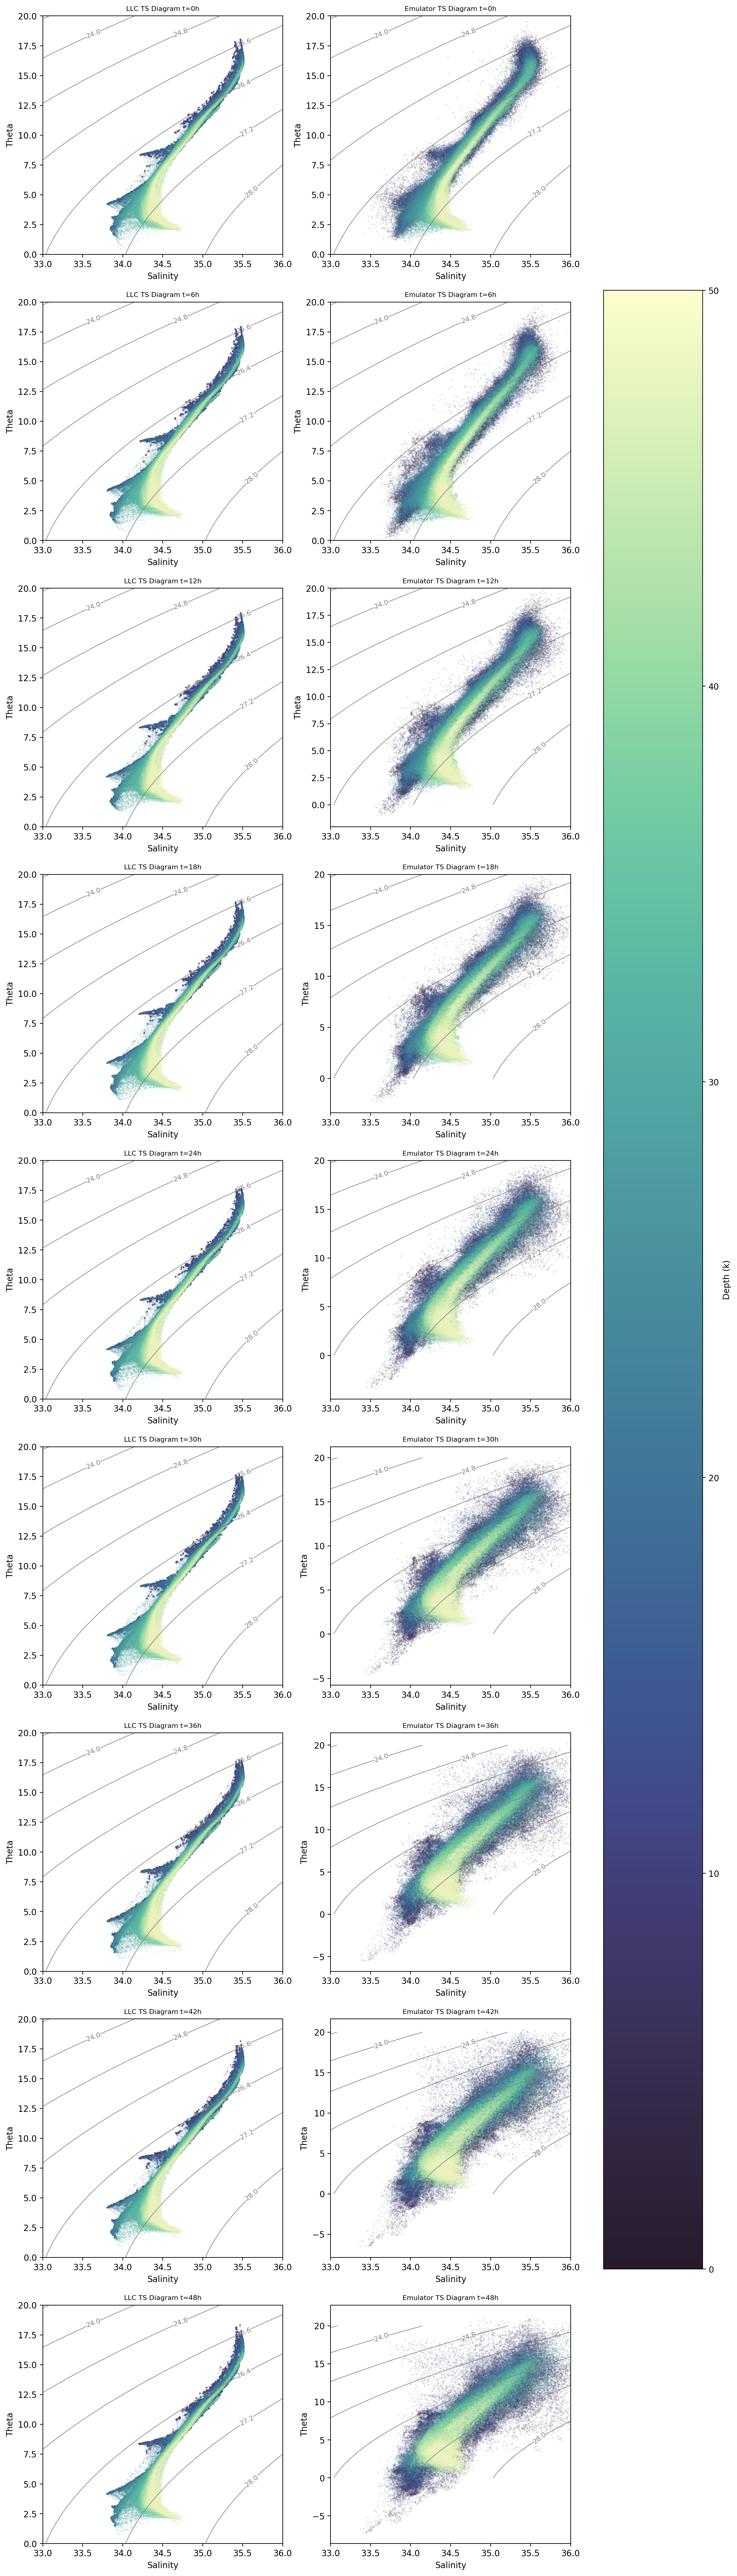

In [4]:
# generate TS grid (only once)
T = np.linspace(0,20,100)
S = np.linspace(33,36,100)
Sg, Tg = np.meshgrid(S,T)
sigma = gsw.sigma0(Sg,Tg)

time_step = 6
time_offsets = list(range(0, 54, time_step))  # [0, 6, 12, 18, 24, 30, 36, 42, 48]
nrows = len(time_offsets)

fig, axes = plt.subplots(nrows, 2, figsize=(14, 6*nrows), dpi=200)

for row, start_offset in enumerate(time_offsets):
    # Load data
    extent = 1
    llc_patch = llc_patch_full.isel(time=slice(start_offset+9216, start_offset+9216 + extent))
    emulator_patch = emulator_patch_full.isel(time=slice(start_offset+0, extent + start_offset))
    
    Theta_hist_llc = llc_patch.Theta.stack(vals=['time','i','j']).values[:,::100]
    Theta_hist_emulator = emulator_patch.Theta.stack(vals=['time','lon','lat']).values[:,::100]
    Salt_hist_llc = llc_patch.Salt.stack(vals=['time','i','j']).values[:,::100]
    Salt_hist_emulator = emulator_patch.Salt.stack(vals=['time','lon','lat']).values[:,::100]
    
    ax1, ax2 = axes[row, 0], axes[row, 1]
    
    # LLC TS diagram
    cs1 = ax1.contour(Sg, Tg, sigma, colors='grey', linewidths=0.7)
    ax1.clabel(cs1, inline=1, fontsize=8, fmt="%.1f")
    for k in range(len(Salt_hist_llc)):
        ax1.scatter(Salt_hist_llc[k], Theta_hist_llc[k], 
                    c=[cmocean.cm.deep_r(k/len(Salt_hist_llc))], s=1, alpha=0.1)
    ax1.set_xlabel("Salinity")
    ax1.set_ylabel("Theta")
    ax1.set_title(f'LLC TS Diagram t={start_offset}h', fontsize=8)
    ax1.set_xlim(33, 36)
    
    # Emulator TS diagram
    cs2 = ax2.contour(Sg, Tg, sigma, colors='grey', linewidths=0.7)
    ax2.clabel(cs2, inline=1, fontsize=8, fmt="%.1f")
    for k in range(len(Salt_hist_emulator)):
        ax2.scatter(Salt_hist_emulator[k], Theta_hist_emulator[k], 
                    c=[cmocean.cm.deep_r(k/len(Salt_hist_emulator))], s=1, alpha=0.1)
    ax2.set_xlabel("Salinity")
    ax2.set_ylabel("Theta")
    ax2.set_title(f'Emulator TS Diagram t={start_offset}h', fontsize=8)
    ax2.set_xlim(33, 36)

# Shared depth colorbar
sm = plt.cm.ScalarMappable(cmap=cmocean.cm.deep_r, norm=plt.Normalize(vmin=0, vmax=len(Salt_hist_llc)-1))
sm.set_array([])
plt.colorbar(sm, ax=axes.flatten(), label='Depth (k)')

#plt.tight_layout()
plt.savefig('figs/TS/LLC_vs_Emulator_TS_timeseries.png')
plt.show()
#plt.close()